In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import joblib

# --------------------
# Example Data Setup
# --------------------
# Replace this with your actual dataset loading

df = pd.read_csv("./flight.csv")
df['Month'] = pd.to_datetime(df['Month'])


# --------------------
# Scaling the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['Passengers'].values.reshape(-1, 1))


# --------------------
# Sequence Creation Function
# --------------------
def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

# --------------------
# Model 0 (3 timesteps)
# --------------------
time_steps_0 = 3
X0, y0 = create_sequences(scaled_data, time_steps_0)
X0 = X0.reshape((X0.shape[0], X0.shape[1], 1))  # reshape to (samples, timesteps, features)

model0 = Sequential()
model0.add(SimpleRNN(50, activation='tanh', input_shape=(time_steps_0, 1)))
model0.add(Dense(1))
model0.compile(optimizer='adam', loss='mse')
model0.fit(X0, y0, epochs=200, batch_size=4, verbose=1)
joblib.dump(model0, "model0.joblib")

# --------------------
# Model 1 (8 timesteps)
# --------------------
time_steps_1 = 8
X1, y1 = create_sequences(scaled_data, time_steps_1)
X1 = X1.reshape((X1.shape[0], X1.shape[1], 1))  # reshape to (samples, timesteps, features)

model1 = Sequential()
model1.add(SimpleRNN(50, activation='tanh', input_shape=(time_steps_1, 1)))
model1.add(Dense(1))
model1.compile(optimizer='adam', loss='mse')
model1.fit(X1, y1, epochs=200, batch_size=4, verbose=1)
joblib.dump(model1, "model1.joblib")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0262
Epoch 2/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0111
Epoch 3/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0113
Epoch 4/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0116
Epoch 5/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0099
Epoch 6/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0084
Epoch 7/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0059
Epoch 8/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0077
Epoch 9/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062
Epoch 10/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0056
Epoch 11/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0052
Epoch 12/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062
Epoch 13/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0052
Epoch 14/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0045
Epoch 15/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0043
Epoc

['model1.joblib']

In [ ]:
model0 = joblib.load("model0.joblib")
model1 = joblib.load("model1.joblib")

predictions0 = model0.predict(X0)
predictions1 = model1.predict(X1)

# Inverse transform the predictions
predictions0 = scaler.inverse_transform(predictions0)
predictions1 = scaler.inverse_transform(predictions1)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [ ]:
df.head(), df.shape

(       Month  Passengers
 0 1949-01-01         112
 1 1949-02-01         118
 2 1949-03-01         132
 3 1949-04-01         129
 4 1949-05-01         121,
 (144, 2))

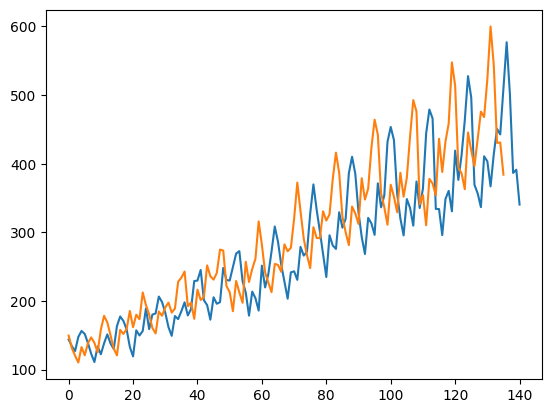

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.plot(predictions0)
plt.plot(predictions1)


In [ ]:
predictions0 = predictions0.reshape(-1)

In [ ]:
initial_values = df['Passengers'].values[:time_steps_0].reshape(-1)  # shape (3,1)
predictions0_padded = np.concatenate((initial_values, predictions0), axis=0)

initial_values


array([112, 118, 132])

In [ ]:
df.Passengers.shape, df.Month.shape, predictions0.shape

((144,), (144,), (141,))

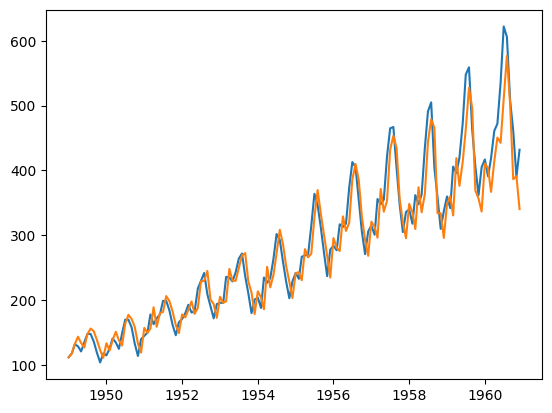

In [ ]:
plt.plot(df['Month'], df['Passengers'])
plt.plot(df['Month'], predictions0_padded)


In [ ]:
"sns.scatterplot(df['Passengers'], df['Month'])

KeyError: 'Month'

In [ ]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import joblib
from sklearn.pipeline import Pipeline


df = pd.read_csv("./flight.csv")
df['Month'] = pd.to_datetime(df['Month'])


scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['Passengers'].values.reshape(-1, 1))


def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)



time_steps_0 = 3
X0, y0 = create_sequences(scaled_data, time_steps_0)
X0 = X0.reshape((X0.shape[0], X0.shape[1], 1))  # reshape to (samples, timesteps, features)

model0 = Sequential()
model0.add(SimpleRNN(50, activation='tanh', input_shape=(time_steps_0, 1)))
model0.add(Dense(1))
model0.compile(optimizer='adam', loss='mse')
model0.fit(X0, y0, epochs=200, batch_size=4, verbose=1)
joblib.dump(model0, "model0.joblib")

# --------------------
# Model 1 (8 timesteps)
# --------------------
time_steps_1 = 8
X1, y1 = create_sequences(scaled_data, time_steps_1)
X1 = X1.reshape((X1.shape[0], X1.shape[1], 1))  # reshape to (samples, timesteps, features)

model1 = Sequential()
model1.add(SimpleRNN(50, activation='tanh', input_shape=(time_steps_1, 1)))
model1.add(Dense(1))
model1.compile(optimizer='adam', loss='mse')
model1.fit(X1, y1, epochs=200, batch_size=4, verbose=1)
joblib.dump(model1, "model1.joblib")

In [ ]:
arr1 = [1,2,3,4,5]
arr1 = np.array(arr1)
arr1 = arr1.reshape(1,-1)
arr1

array([[1, 2, 3, 4, 5]])

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

class CSV_RNN_PREDICTION_PIPELINE:
  def __init__(self, dataset, time_column_name, prediction_amt, prediction_step, iteration, relative_path_artifacts):
    self.scaler = None
    self.data = dataset
    self.df = pd.read_csv(self.data)
    self.time_col_name = time_column_name
    self.model_path = None
    self.scaler_path  = None
    self.model = None
    self.prediction_amt = prediction_amt
    self.prediction_step = prediction_step
    self.df[self.time_col_name] = pd.to_datetime(self.df[self.time_col_name])
    self.X = None
    self.y = None
    self.X_train = None
    self.X_test = None
    self.y_train = None
    self.y_test = None
    self.iteration = iteration
    self.relative_path_artifacts = relative_path_artifacts
  #alreadey i must convert it to a suitable time format before inputting it to class object

  def train_test_split(self):
    tempX = self.df[self.time_col_name].values.reshape(-1, 1)
    tempY = self.df.drop(columns=[self.time_column_name]).reshape(-1)

    self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(tempX, tempY, test_size=0.2, random_state=42)

  def scale_data(self):
    self.scaler = MinMaxScaler(feature_range=(0, 1))
    self.X_train = self.scaler.fit_transform(self.X_train)
    self.X_test = self.scaler.transform(self.X_test)



  def load_model(self):
    self.model = joblib.load(self.model_path)

  def save_model(self):
    joblib.dump(self.model, self.model_path)

  def save_scaler(self):
    joblib.dump(self.scaler, self.scaler_path)

  def load_scaler(self):
    self.scaler = joblib.load(self.scaler_path)

  def create_sequences(self):
    X, y = [], []
    for i in range(len(self.data) - self.prediction_step):
        X.append(self.data[i:i + self.prediction_step])
        y.append(self.data[i + self.prediction_step])
    return np.array(X), np.array(y)




SyntaxError: incomplete input (ipython-input-2881339284.py, line 1)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import joblib
from sklearn.model_selection import train_test_split

class CSV_RNN_PREDICTION_PIPELINE:
    def __init__(self, dataset, time_column_name, target_column_name,
                 prediction_step, iteration, relative_path_artifacts):
        self.scaler = None
        self.target_scaler = None
        self.data_path = dataset
        self.df = pd.read_csv(self.data_path)
        self.time_col_name = time_column_name
        self.target_col_name = target_column_name
        self.prediction_step = prediction_step
        self.iteration = iteration
        self.relative_path_artifacts = relative_path_artifacts

        self.model_path = f"{self.relative_path_artifacts}/model_{self.iteration}.joblib"
        self.scaler_path = f"{self.relative_path_artifacts}/scaler_{self.iteration}.joblib"
        self.target_scaler_path = f"{self.relative_path_artifacts}/target_scaler_{self.iteration}.joblib"

        self.df[self.time_col_name] = pd.to_datetime(self.df[self.time_col_name])

        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.X_train_seq = None
        self.y_train_seq = None
        self.X_test_seq = None
        self.y_test_seq = None
        self.model = None

    def predict_test_set(self):
      """
      Predicts values for the entire X_test dataset using the trained model
      and returns the predictions in the original scale.

      Parameters:
      - obj: the trained pipeline object

      Returns:
      - predictions_df: DataFrame with original dates and predicted values
      """
      self.load_model()
      self.load_scaler()

      # Create sequences from X_test and y_test (as done during training)
      X_test_seq, y_test_seq = self.create_sequences(self.X_test, self.y_test)

      # Predict for all sequences
      pred_scaled = self.model.predict(X_test_seq)

      # Inverse scale the predictions
      pred_original = self.target_scaler.inverse_transform(pred_scaled)

      # Get corresponding dates: start from the first sequence's end date
      dates = self.df[self.time_col_name].values[-len(y_test_seq):]

      # Build a DataFrame with dates and predictions
      predictions_df = pd.DataFrame({
          'date': pd.to_datetime(dates),
          'prediction': pred_original.flatten()
      })

      return predictions_df


    def extract_time_features(self):
        """Convert datetime to numerical features."""
        self.df['year'] = self.df[self.time_col_name].dt.year
        self.df['month'] = self.df[self.time_col_name].dt.month

    def prepare_data(self):
        """Prepare X and y arrays with time features and target."""
        self.extract_time_features()

        feature_cols = ['year', 'month']

        X = self.df[feature_cols].values
        y = self.df[self.target_col_name].values

        self.X, self.y = X, y

    def train_test_split(self):
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42)

    def scale_data(self):
        self.scaler = MinMaxScaler(feature_range=(0, 1))
        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)

        self.target_scaler = MinMaxScaler(feature_range=(0, 1))
        self.y_train = self.target_scaler.fit_transform(self.y_train.reshape(-1, 1)).flatten()
        self.y_test = self.target_scaler.transform(self.y_test.reshape(-1, 1)).flatten()

    def create_sequences(self, X_data, y_data):
        """Create sequences from the data for RNN."""
        X_seq, y_seq = [], []
        for i in range(len(X_data) - self.prediction_step):
            X_seq.append(X_data[i:i + self.prediction_step])
            y_seq.append(y_data[i + self.prediction_step])
        return np.array(X_seq), np.array(y_seq)

    def build_model(self):
        self.model = Sequential()
        input_shape = (self.prediction_step, self.X_train.shape[1])
        self.model.add(SimpleRNN(50, activation='tanh', input_shape=input_shape))
        self.model.add(Dense(1))
        self.model.compile(optimizer='adam', loss='mse')

    def train_model(self, epochs=50, batch_size=16):
        self.model.fit(self.X_train_seq, self.y_train_seq, epochs=epochs, batch_size=batch_size, verbose=1)

    def save_model(self):
        joblib.dump(self.model, self.model_path)

    def load_model(self):
        self.model = joblib.load(self.model_path)

    def save_scaler(self):
        joblib.dump(self.scaler, self.scaler_path)
        joblib.dump(self.target_scaler, self.target_scaler_path)

    def load_scaler(self):
        self.scaler = joblib.load(self.scaler_path)
        self.target_scaler = joblib.load(self.target_scaler_path)

    def run_pipeline(self):
        self.prepare_data()
        self.train_test_split()
        self.scale_data()

        self.X_train_seq, self.y_train_seq = self.create_sequences(self.X_train, self.y_train)
        self.X_test_seq, self.y_test_seq = self.create_sequences(self.X_test, self.y_test)

        self.build_model()
        self.train_model()

        self.save_model()
        self.save_scaler()

    def predict(self, time_series):
        """
        Predicts the output for the given time_series and returns the result inversely scaled.

        Parameters:
        - time_series (np.ndarray): Input shaped as (1, prediction_step, num_features)

        Returns:
        - prediction (np.ndarray): Prediction in original scale.
        """
        if self.model is None:
            raise ValueError("Model is not loaded or trained.")
        if self.scaler is None or self.target_scaler is None:
            raise ValueError("Scaler or target scaler is not loaded.")

        prediction_scaled = self.model.predict(time_series)
        prediction_original = self.target_scaler.inverse_transform(prediction_scaled)
        return prediction_original


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1831
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1095 
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0698 
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0651 
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0651 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0621  
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0637 
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0603 
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0495 
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0577 
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0662 
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0576 
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0666  
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0568 
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0623 
Epoch 16/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/

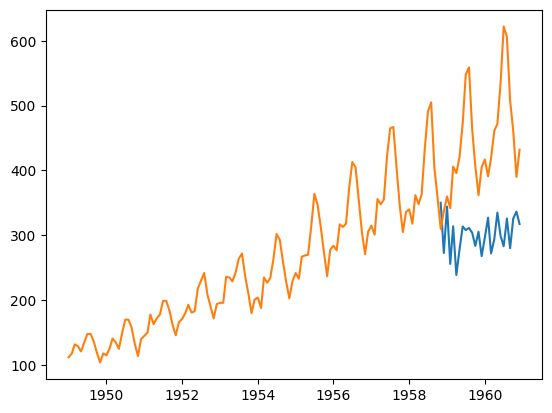

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3257
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1263  
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0769 
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1049 
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0690 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0723 
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0752 
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0620  
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0606 
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0576 
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0676 
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0579 
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0542 
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0537 
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0489 
Epoch 16/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/

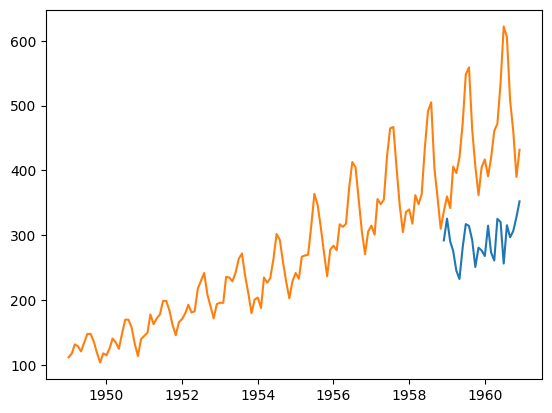

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1732
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0860 
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0582 
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0729 
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0610  
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0593 
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0593  
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0569 
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0622 
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0526 
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0505  
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0567 
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0600 
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0478  
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0586 
Epoch 16/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7m

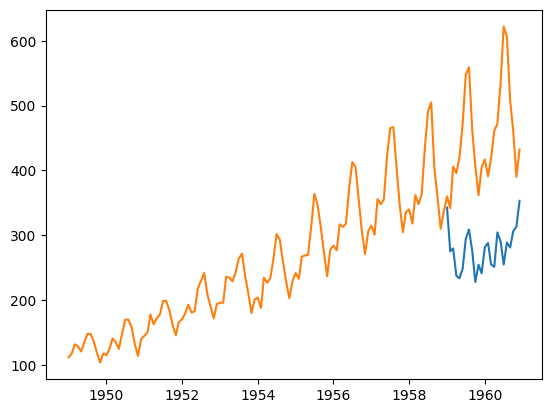

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1116
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0606 
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0618 
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0608 
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0537 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0518 
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0570 
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0449  
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0627 
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0507 
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0511 
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0542 
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0548  
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0585  
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0521 
Epoch 16/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms

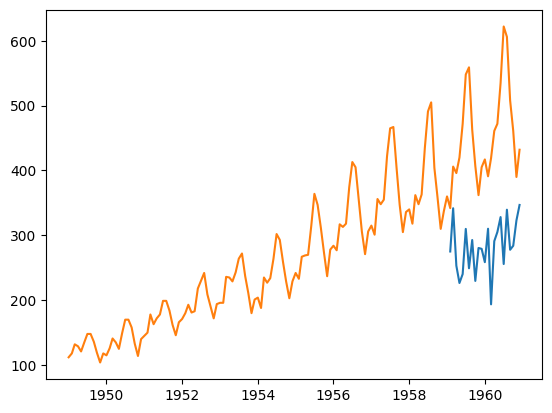

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1388
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0803 
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0822 
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0609 
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0531
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0541 
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0617 
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0484 
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0468 
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0556
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0497
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0540
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0524
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0561
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0460
Epoch 16/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/s

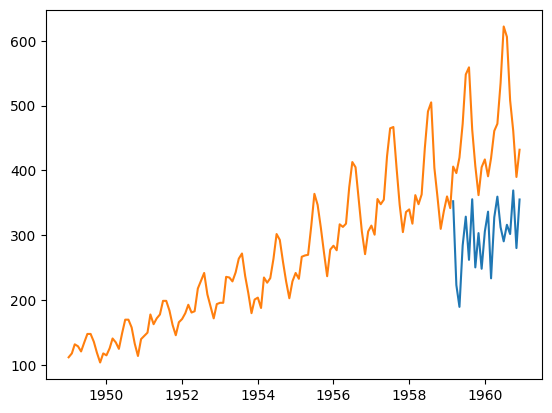

In [ ]:
for i in range(3,8):

  obj = CSV_RNN_PREDICTION_PIPELINE("./flight.csv", "Month", "Passengers", i, 0, "./artifacts")
  obj.run_pipeline()
  predictions_test = obj.predict_test_set()
  plt.plot(predictions_test['date'], predictions_test['prediction'])
  plt.plot(df['Month'], df['Passengers'])
  plt.show()

In [ ]:
obj.run_pipeline()

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1358
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0817 
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0687 
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0704  
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0532 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0582 
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0474 
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0587 
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0589 
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0545 
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0575 
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0642 
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0553 
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0558 
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0534 
Epoch 16/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/s

In [ ]:
predictions_test

,date,prediction
0,1959-03-01,352.565918
1,1959-04-01,223.437347
2,1959-05-01,189.743622
3,1959-06-01,284.375458
4,1959-07-01,328.801880
5,1959-08-01,262.228699
6,1959-09-01,355.625061
7,1959-10-01,250.568573
8,1959-11-01,303.462402
9,1959-12-01,248.497849


In [ ]:
# # Assuming obj is an instance of CSV_RNN_PREDICTION_PIPELINE
# # and the pipeline has already been trained or loaded.

# # Make sure the model and scalers are loaded
# obj.load_model()
# obj.load_scaler()

# # Prepare the sample input: first test sequence
# sample_input = obj.X_test_seq[0].reshape(1, obj.prediction_step, obj.X_train.shape[1])

# # Perform prediction and get the output in original scale
# result = obj.predict(sample_input)

# # Print the prediction
# print("Predicted value in original scale:", result.flatten()[0])



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Predicted value in original scale: 322.9774


In [ ]:
predictions_test = obj.predict_test_set()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


In [ ]:
predictions_test

,date,prediction
0,1959-01-01,322.977295
1,1959-02-01,266.905457
2,1959-03-01,299.634003
3,1959-04-01,194.480042
4,1959-05-01,222.504166
5,1959-06-01,234.685394
6,1959-07-01,290.634949
7,1959-08-01,304.758942
8,1959-09-01,267.878357
9,1959-10-01,195.814514


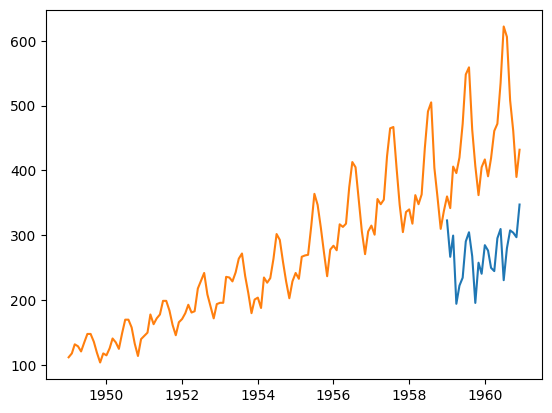

In [ ]:
plt.plot(predictions_test['date'], predictions_test['prediction'])
plt.plot(df['Month'], df['Passengers'])

In [ ]:
import numpy as np
import pandas as pd

def predict_range(obj, start_date, end_date):
    """
    Predict from start_date to end_date iteratively.

    Parameters:
    - obj: the trained pipeline object
    - start_date (str): e.g., '1950-06'
    - end_date (str): e.g., '1951-12'

    Returns:
    - predictions_df: DataFrame with dates and predicted values
    """
    # Ensure model and scalers are loaded
    obj.load_model()
    obj.load_scaler()

    # Convert dates to datetime
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    # Sort dataframe by time
    df = obj.df.sort_values(by=obj.time_col_name).reset_index(drop=True)

    # Find the last known sequence before start_date
    past_data = df[df[obj.time_col_name] < start_date]
    if len(past_data) < obj.prediction_step:
        raise ValueError("Not enough past data to create initial sequence.")

    # Take the last `prediction_step` rows before start_date
    initial_seq = past_data.iloc[-obj.prediction_step:]

    # Extract features (year, month)
    feature_data = initial_seq[['year', 'month']].values

    # Scale features
    scaled_features = obj.scaler.transform(feature_data)

    # Prepare sequence
    current_seq = scaled_features.copy()

    # Generate all future dates from start_date to end_date
    future_dates = pd.date_range(start=start_date, end=end_date, freq='MS')

    predictions = []

    for date in future_dates:
        # Reshape to (1, prediction_step, num_features)
        input_seq = current_seq.reshape(1, obj.prediction_step, obj.X_train.shape[1])

        # Predict scaled value
        pred_scaled = obj.model.predict(input_seq)

        # Inverse scale to original
        pred_original = obj.target_scaler.inverse_transform(pred_scaled)[0, 0]

        predictions.append({'date': date, 'prediction': pred_original})

        # Prepare next sequence
        # Create new feature for current date
        new_feature = np.array([[date.year, date.month]])
        new_feature_scaled = obj.scaler.transform(new_feature)

        # Append predicted value's feature to sequence by removing first and adding new
        current_seq = np.vstack([current_seq[1:], new_feature_scaled])

    predictions_df = pd.DataFrame(predictions)
    return predictions_df


In [ ]:
# obj is your trained pipeline instance
predictions_df = predict_range(obj, start_date=df.iloc[4][0], end_date=df.iloc[0][-1])

print(predictions_df)


/tmp/ipython-input-1902341303.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  predictions_df = predict_range(obj, start_date=df.iloc[4][0], end_date=df.iloc[0][-1])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━

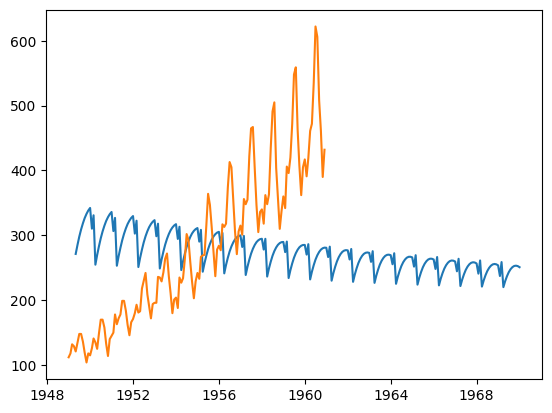

In [ ]:
plt.plot(predictions_df['date'], predictions_df['prediction'])
plt.plot(df['Month'], df['Passengers'])

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import joblib

class CSV_LSTM_PREDICTION_PIPELINE:
    def __init__(self, dataset, time_column_name, target_column_name,
                 prediction_step, iteration, relative_path_artifacts):
        self.data_path = dataset
        self.df = pd.read_csv(self.data_path)
        self.time_col_name = time_column_name
        self.target_col_name = target_column_name
        self.prediction_step = prediction_step
        self.iteration = iteration
        self.relative_path_artifacts = relative_path_artifacts

        self.model_path = f"{self.relative_path_artifacts}/lstm_model_{self.iteration}.joblib"
        self.scaler_path = f"{self.relative_path_artifacts}/lstm_scaler_{self.iteration}.joblib"
        self.target_scaler_path = f"{self.relative_path_artifacts}/lstm_target_scaler_{self.iteration}.joblib"

        self.df[self.time_col_name] = pd.to_datetime(self.df[self.time_col_name])

        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.model = None

        self.scaler = None
        self.target_scaler = None

    def extract_time_features(self):
        """Convert datetime to numerical features."""
        self.df['year'] = self.df[self.time_col_name].dt.year
        self.df['month'] = self.df[self.time_col_name].dt.month

    def prepare_data(self):
        """Prepare features and target arrays."""
        self.extract_time_features()
        feature_cols = ['year', 'month']
        self.X = self.df[feature_cols].values
        self.y = self.df[self.target_col_name].values.reshape(-1, 1)

    def train_test_split(self, test_size=0.2):
        split_idx = int(len(self.X) * (1 - test_size))
        self.X_train = self.X[:split_idx]
        self.X_test = self.X[split_idx:]
        self.y_train = self.y[:split_idx]
        self.y_test = self.y[split_idx:]

    def scale_data(self):
        self.scaler = MinMaxScaler(feature_range=(0, 1))
        self.target_scaler = MinMaxScaler(feature_range=(0, 1))

        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)

        self.y_train = self.target_scaler.fit_transform(self.y_train)
        self.y_test = self.target_scaler.transform(self.y_test)

    def create_sequences(self, X_data, y_data):
        """Create sequences for LSTM."""
        X_seq, y_seq = [], []
        for i in range(len(X_data) - self.prediction_step):
            X_seq.append(X_data[i:i + self.prediction_step])
            y_seq.append(y_data[i + self.prediction_step])
        return np.array(X_seq), np.array(y_seq)

    def build_model(self):
        self.model = Sequential()
        input_shape = (self.prediction_step, self.X_train.shape[1])
        self.model.add(LSTM(50, activation='tanh', input_shape=input_shape))
        self.model.add(Dense(1))
        self.model.compile(optimizer='adam', loss='mse')

    def train_model(self, epochs=50, batch_size=16):
        self.X_train_seq, self.y_train_seq = self.create_sequences(self.X_train, self.y_train)
        self.X_test_seq, self.y_test_seq = self.create_sequences(self.X_test, self.y_test)
        self.build_model()
        self.model.fit(self.X_train_seq, self.y_train_seq, epochs=epochs,
                       batch_size=batch_size, verbose=1)

    def save_model(self):
        joblib.dump(self.model, self.model_path)
        joblib.dump(self.scaler, self.scaler_path)
        joblib.dump(self.target_scaler, self.target_scaler_path)

    def load_model(self):
        self.model = joblib.load(self.model_path)
        self.scaler = joblib.load(self.scaler_path)
        self.target_scaler = joblib.load(self.target_scaler_path)

    def predict_sequence(self, input_seq):
        """Predict a single sequence and return in original scale."""
        pred_scaled = self.model.predict(input_seq)
        return self.target_scaler.inverse_transform(pred_scaled)

    def extrapolate(self, start_date, end_date):
        """
        Predict values from start_date to end_date iteratively.
        Returns a DataFrame with 'date' and 'prediction' columns.
        """
        self.load_model()
        start_date = pd.to_datetime(start_date)
        end_date = pd.to_datetime(end_date)
        df_sorted = self.df.sort_values(by=self.time_col_name).reset_index(drop=True)

        # Get last sequence before start_date
        past_data = df_sorted[df_sorted[self.time_col_name] < start_date]
        if len(past_data) < self.prediction_step:
            raise ValueError("Not enough past data to create initial sequence.")
        initial_seq = past_data.iloc[-self.prediction_step:]
        feature_seq = initial_seq[['year', 'month']].values
        scaled_seq = self.scaler.transform(feature_seq)
        current_seq = scaled_seq.copy()

        future_dates = pd.date_range(start=start_date, end=end_date, freq='MS')
        predictions = []

        for date in future_dates:
            # Reshape and predict
            input_seq = current_seq.reshape(1, self.prediction_step, self.X_train.shape[1])
            pred = self.predict_sequence(input_seq)[0, 0]
            predictions.append({'date': date, 'prediction': pred})

            # Update sequence with new date
            new_feature = np.array([[date.year, date.month]])
            new_feature_scaled = self.scaler.transform(new_feature)
            current_seq = np.vstack([current_seq[1:], new_feature_scaled])

        return pd.DataFrame(predictions)



    def predict_X_test(self):
        """
        Predicts for the X_test set and returns actual vs predicted in original scale.
        """
        self.load_model()
        # Create sequences for X_test
        X_test_seq, y_test_seq = self.create_sequences(self.X_test, self.y_test)

        # Predict
        y_pred_scaled = self.model.predict(X_test_seq)
        y_pred = self.target_scaler.inverse_transform(y_pred_scaled)
        y_actual = self.target_scaler.inverse_transform(y_test_seq)

        return y_actual.flatten(), y_pred.flatten()

    def plot_X_test_predictions(self):
        """
        Plots actual vs predicted values for X_test.
        """
        y_actual, y_pred = self.predict_X_test()
        plt.figure(figsize=(12, 6))
        plt.plot(y_actual, label='Actual', marker='o')
        plt.plot(y_pred, label='Predicted', marker='x')
        plt.title("LSTM Predictions vs Actual Values on X_test")
        plt.xlabel("Time Step")
        plt.ylabel(self.target_col_name)
        plt.legend()
        plt.show()



# Initialize pipeline
obj = CSV_LSTM_PREDICTION_PIPELINE(
    dataset="../datasets/flight.csv",
    time_column_name="Month",
    target_column_name="Passengers",
    prediction_step=3,
    iteration=1,
    relative_path_artifacts="artifacts"
)

# Prepare data, scale, and train
obj.prepare_data()
obj.train_test_split()
obj.scale_data()
obj.train_model(epochs=100, batch_size=4)
obj.save_model()

# Extrapolate predictions from a specific date
pred_df = obj.extrapolate(start_date="1958-01", end_date="1970-12")
print(pred_df)



Epoch 1/100
28/28 [==============================] - 1s 2ms/step - loss: 0.0979
Epoch 2/100
28/28 [==============================] - 0s 2ms/step - loss: 0.0309
Epoch 3/100
28/28 [==============================] - 0s 2ms/step - loss: 0.0147
Epoch 4/100
28/28 [==============================] - 0s 2ms/step - loss: 0.0077
Epoch 5/100
28/28 [==============================] - 0s 2ms/step - loss: 0.0068
Epoch 6/100
28/28 [==============================] - 0s 2ms/step - loss: 0.0069
Epoch 7/100
28/28 [==============================] - 0s 2ms/step - loss: 0.0064
Epoch 8/100
28/28 [==============================] - 0s 1ms/step - loss: 0.0071
Epoch 9/100
28/28 [==============================] - 0s 1ms/step - loss: 0.0064
Epoch 10/100
28/28 [==============================] - 0s 2ms/step - loss: 0.0070
Epoch 11/100
28/28 [==============================] - 0s 1ms/step - loss: 0.0065
Epoch 12/100
28/28 [==============================] - 0s 2ms/step - loss: 0.0064
Epoch 13/100
28/28 [=================

1/1 [==============================] - 0s 283ms/step


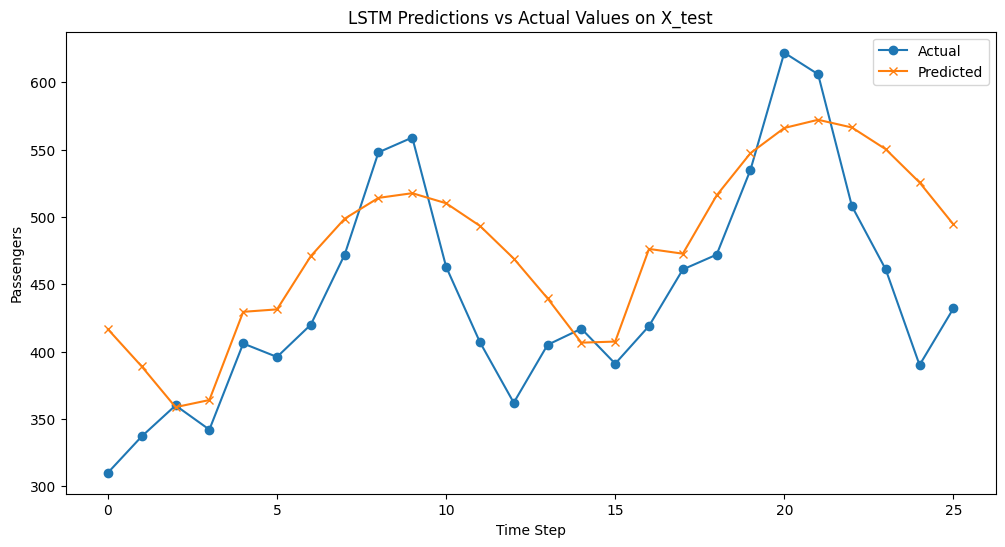

In [6]:
import matplotlib.pyplot as plt

# After training and saving your LSTM model
obj.plot_X_test_predictions()



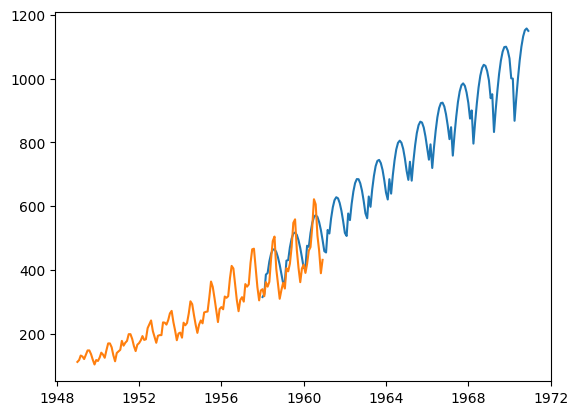

In [9]:
df = pd.read_csv("../datasets/flight.csv")
df['Month'] = pd.to_datetime(df['Month'])
plt.plot(pred_df['date'], pred_df['prediction'])
plt.plot(df['Month'], df['Passengers'])

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
